In [ ]:
!pip -q install networkx

import networkx as nx

G = nx.Graph()

# 1. เพิ่ม User (10 คน)
users = [
    "Alice", "Bob", "Charlie", "David", "Eve",
    "Frank", "Grace", "Heidi", "Ivan", "Judy"
]
for user in users:
    G.add_node(user, node_type="user")

# 2. เพิ่ม เพลง (20 เพลง)
songs = [
    "Bohemian Rhapsody", "Shape of You", "Blinding Lights", "Hotel California",
    "Rolling in the Deep", "Watermelon Sugar", "Billie Jean", "Hey Jude",
    "Uptown Funk", "Smells Like Teen Spirit", "Thinking Out Loud", "Someone Like You",
    "Perfect", "Dance Monkey", "Let It Be", "Yesterday", "Havana",
    "Bad Guy", "Wonderwall", "Hallelujah"
]
for song in songs:
    G.add_node(song, node_type="song")

print(f"เพิ่มข้อมูลสำเร็จ: มี {len(users)} Users และ {len(songs)} เพลง")

เพิ่มข้อมูลสำเร็จ: มี 10 Users และ 20 เพลง


In [ ]:
# 3. เพิ่มความสัมพันธ์ (ใครชอบเพลงอะไร)
likes = [
    ("Alice", "Bohemian Rhapsody"), ("Alice", "Hotel California"), ("Alice", "Hey Jude"),
    ("Bob", "Shape of You"), ("Bob", "Watermelon Sugar"), ("Bob", "Uptown Funk"),
    ("Charlie", "Blinding Lights"), ("Charlie", "Watermelon Sugar"), ("Charlie", "Bad Guy"),
    ("David", "Hotel California"), ("David", "Smells Like Teen Spirit"), ("David", "Wonderwall"),
    ("Eve", "Rolling in the Deep"), ("Eve", "Someone Like You"), ("Eve", "Hallelujah"),
    ("Frank", "Shape of You"), ("Frank", "Perfect"), ("Frank", "Thinking Out Loud"),
    ("Grace", "Billie Jean"), ("Grace", "Uptown Funk"), ("Grace", "Bohemian Rhapsody"),
    ("Heidi", "Dance Monkey"), ("Heidi", "Havana"), ("Heidi", "Bad Guy"),
    ("Ivan", "Let It Be"), ("Ivan", "Yesterday"), ("Ivan", "Hey Jude"),
    ("Judy", "Hallelujah"), ("Judy", "Yesterday"), ("Judy", "Rolling in the Deep"), ("Judy", "Perfect")
]

G.add_edges_from(likes)

# ทดสอบดึงข้อมูลว่า Alice ชอบเพลงอะไร
alice_movies = list(G.neighbors("Alice"))
print("เพลงที่ Alice ชอบ:", alice_movies)

เพลงที่ Alice ชอบ: ['Bohemian Rhapsody', 'Hotel California', 'Hey Jude']


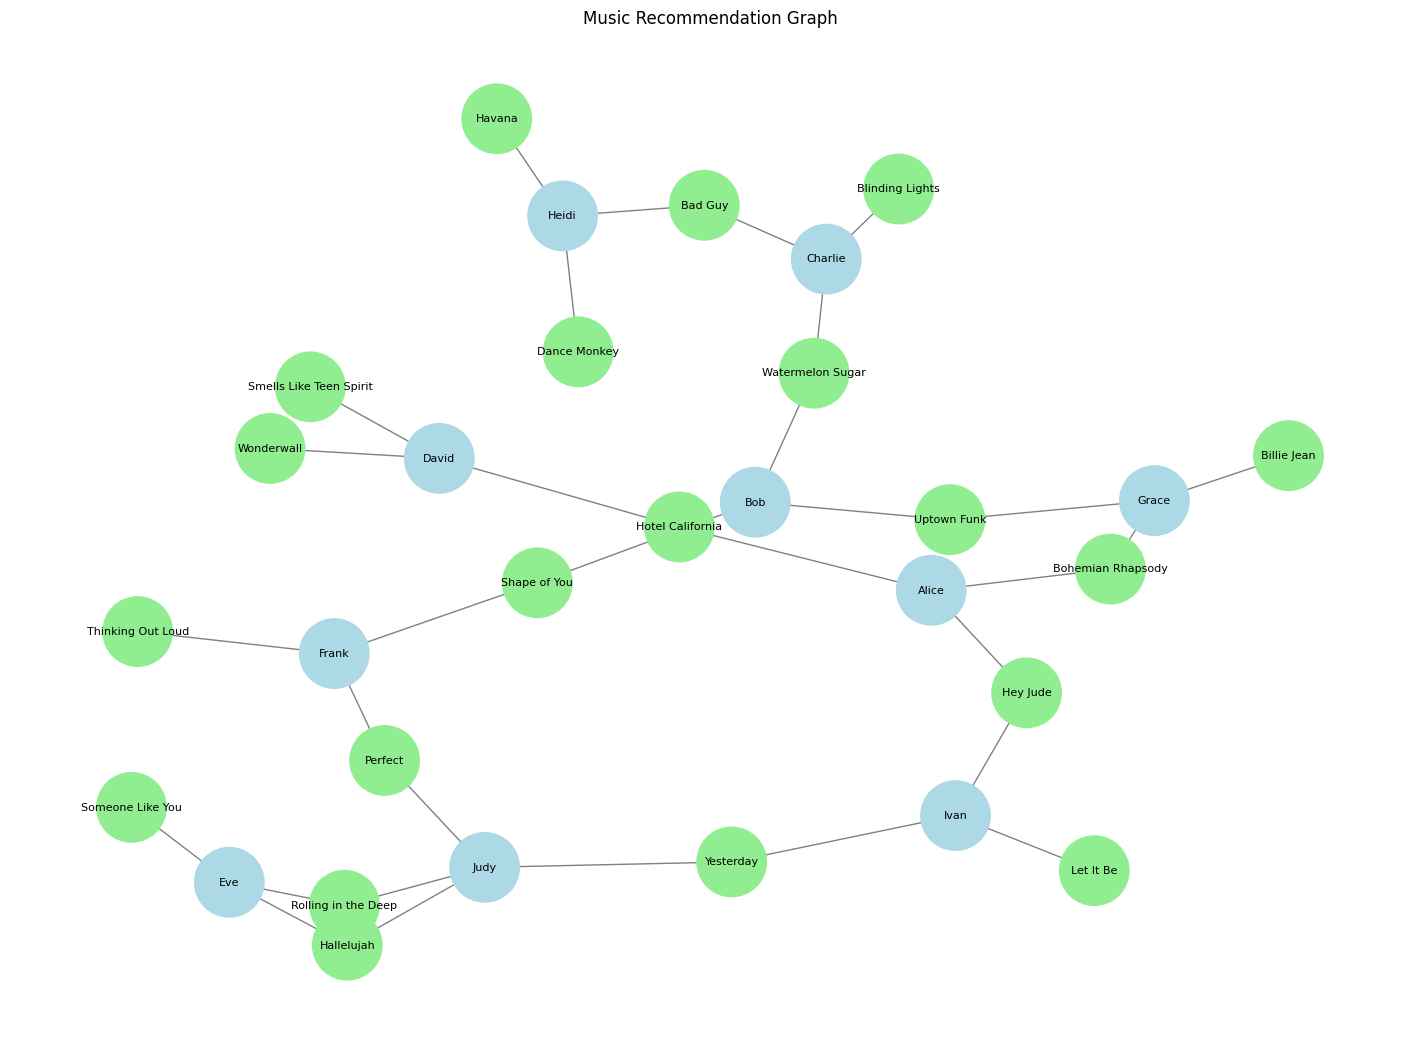

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10)) # ขนาด
pos = nx.spring_layout(G, seed=42, k=0.3) #ควบคุมระยะห่างระหว่าง Node

# กำหนดสีให้ User และ Song
node_colors = ['lightblue' if G.nodes[n]['node_type'] == 'user' else 'lightgreen' for n in G.nodes] #ถ้า Node เป็น User ให้สีฟ้า ถ้าไม่ใช่ User ให้สีเขียว

nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=2500,
    font_size=8,
    edge_color='gray'
)
plt.title("Music Recommendation Graph")
plt.show()

In [ ]:
from collections import Counter

def recommend_songs(G, target_user):
    recommendations = Counter()
    liked_songs = set(G.neighbors(target_user)) #neighbors() หมายถึง หาสิ่งที่เชื่อมต่อกับ Node นั้น

    for song in liked_songs: #การวนดูเพลงที่ User ชอบทีละเพลง
        for similar_user in G.neighbors(song): #หาคนอื่นที่ชอบเพลงเดียวกัน     similar_user User คนอื่นที่ชอบเพลงเดียวกัน
            if similar_user == target_user: # ถ้าเจอตัวเองก็จะไม่เอามาคำนวน
                continue

            for other_song in G.neighbors(similar_user): #ดูว่า User ที่คล้ายกันชอบเพลงอะไร      other_song  เพลงที่ similar_user ชอบ
                if other_song not in liked_songs: #ไม่แนะนำเพลงที่ User ชอบอยู่แล้ว
                    recommendations[other_song] += 1 # เพิ่มคะแนนเพลงที่แนะนำ

    return recommendations.most_common() #most_common() จะเรียงเพลงตามจำนวนครั้งที่พบ

# ดูผลลัพธ์การแนะนำเพลงให้ Alice, Bob และ Judy
print("แนะนำเพลงให้ Alice:", recommend_songs(G, "Alice"))
print("แนะนำเพลงให้ Bob:", recommend_songs(G, "Bob"))
print("แนะนำเพลงให้ Judy:", recommend_songs(G, "Judy"))

แนะนำเพลงให้ Alice: [('Let It Be', 1), ('Yesterday', 1), ('Smells Like Teen Spirit', 1), ('Wonderwall', 1), ('Billie Jean', 1), ('Uptown Funk', 1)]
แนะนำเพลงให้ Bob: [('Billie Jean', 1), ('Bohemian Rhapsody', 1), ('Perfect', 1), ('Thinking Out Loud', 1), ('Blinding Lights', 1), ('Bad Guy', 1)]
แนะนำเพลงให้ Judy: [('Someone Like You', 2), ('Let It Be', 1), ('Hey Jude', 1), ('Shape of You', 1), ('Thinking Out Loud', 1)]


In [ ]:
print("แนะนำเพลงให้ Alice:", recommend_songs(G, "Alice"))

NameError: name 'recommend_songs' is not defined